In [1]:
from lib.get_L2_cuda import *
from lib.ulam import *
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt 
from multiprocessing import Pool
import itertools
import tqdm
import seaborn as sns
from scipy.stats import special_ortho_group
import k3d
from tqdm import tqdm
import matplotlib.cm as cm

In [2]:
seed = np.random.SeedSequence()
gen = np.random.Generator(np.random.MT19937(seed))

In [3]:
Nlist = np.unique(np.logspace(0,3.5,50, dtype=int))

# Figure 4

### subplot a.

/mnt/lustre-grete/projects/nhr_ni_starter_22625/env_jupyter/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y,device = dev)


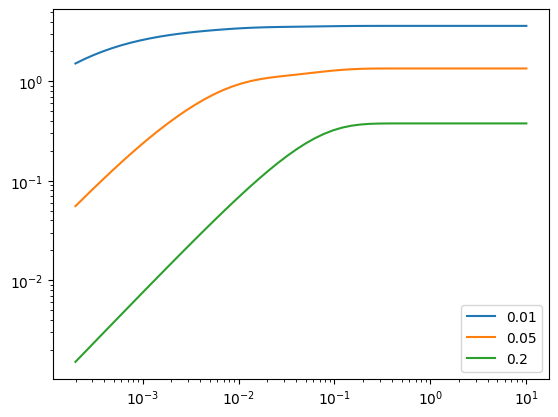

In [4]:
Res = 1000
x_e = y_e = torch.linspace(0,1,Res+1, device = dev)[:-1]
X,Y = torch.meshgrid(y_e,x_e)
epsL = torch.logspace(-3.7,1,50, device = dev)
for i, std in enumerate([.01,.05,.2]):
    dens = dens_gauss_shift(X,Y, 0.3, (std**2 + epsL)**.5)
    dens2 = dens_gauss_shift(X,Y,0.3, std)
    l2 = (torch.sum((dens-dens2)**2, dim = (1,2)))**.5/dens.shape[-1]
    plt.plot(epsL.cpu(), l2.cpu(), label = f"{std}")
plt.xscale('log')
plt.yscale('log')
plt.legend()


### subplots b. and d.

In [15]:
Data_bd = get_torus_simulation(gen, Nlist, stdL = [.01], epsL = [.001,.0025,.01], shift = .3, shift_prob = .5, dim = 1, N_sim = 100, n_sim = 500).round(5)
# Data_bd = pd.read_csv('./TorusData/Fig4_bd.csv')

/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y,device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  o = torch.ceil(torch.tensor(4 * std).to(dev))
100%|██████████| 44/44 [19:36<00:00, 26.75s/it]


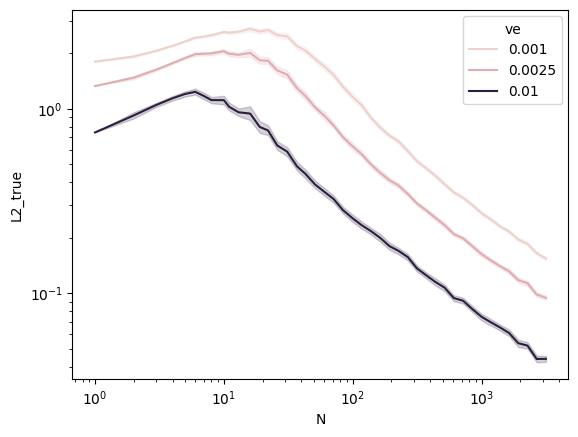

In [16]:
sns.lineplot(Data_bd, x = 'N', y = 'L2_true', hue = 've')
plt.xscale('log')
plt.yscale('log')

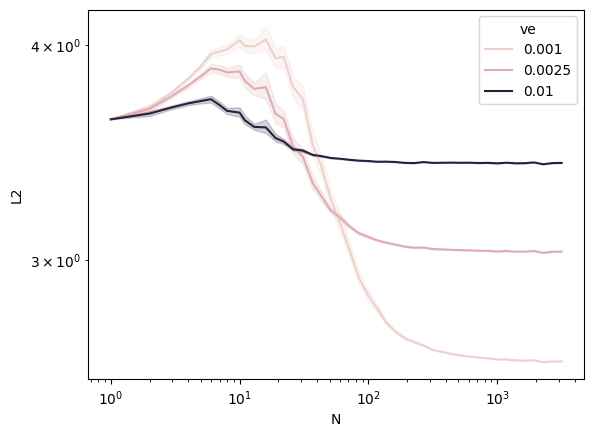

In [18]:
sns.lineplot(Data_bd, x = 'N', y = 'L2', hue = 've')
plt.xscale('log')
plt.yscale('log')

### subplot c.

In [22]:
Data_c = get_torus_simulation(gen, Nlist, stdL = [.01,.05,.2], epsL = [0.001], shift = .3, shift_prob = .5, dim = 1, N_sim = 100, n_sim = 500).round(5)
# Data_c = pd.read_csv('./Given_results_torus/Fig4_c.csv')

/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y,device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  o = torch.ceil(torch.tensor(4 * std).to(dev))
100%|██████████| 132/132 [34:59<00:00, 15.90s/it]


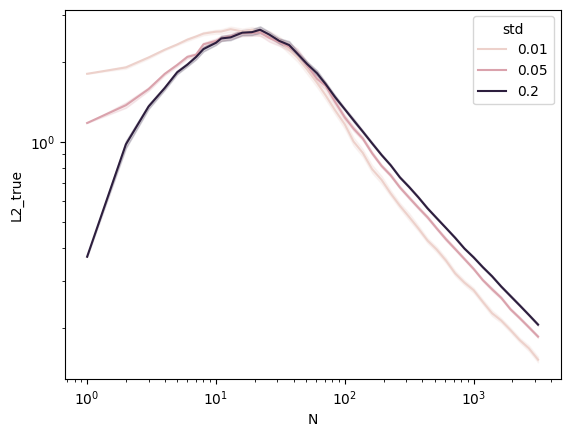

In [32]:
sns.lineplot(Data_c, x = 'N', y = 'L2_true', hue = 'std')
plt.xscale('log')
plt.yscale('log')

### subplot e.

In [5]:
Data_e = get_torus_simulation(gen, Nlist = [100], stdL = [.01,.05,.2], epsL = np.logspace(-4,0,50), shift = .3, shift_prob = .5, dim = 1, N_sim = 100, n_sim = 500).round(5)
# Data_e = pd.read_csv('./Given_results_torus/Fig4_e.csv')

100%|██████████| 3/3 [02:26<00:00, 48.72s/it]


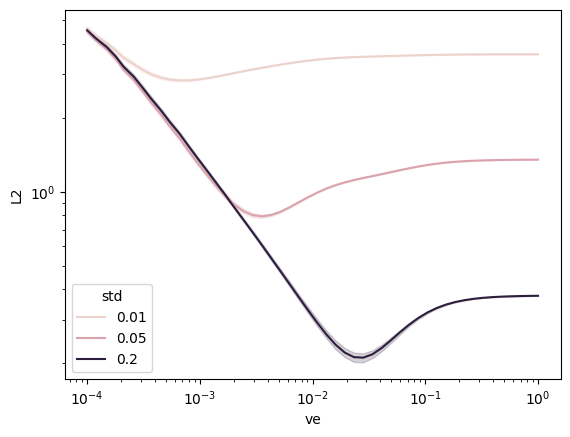

In [6]:
sns.lineplot(Data_e, x = 've', y = 'L2', hue = 'std')
plt.xscale('log')
plt.yscale('log')

### subplot f.

In [2]:
Data_f = get_torus_simulation(gen, Nlist = [100, 1000, 10000], stdL = [0.1], epsL = np.logspace(-4,0,50), shift = .3, shift_prob = .5, dim = 1, N_sim = 100, n_sim = 500).round(5)
# Data_f = pd.read_csv('./Given_results_torus/Fig4_f.csv')

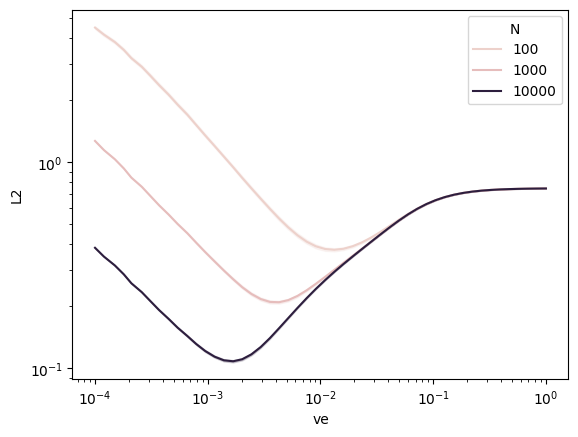

In [5]:
sns.lineplot(Data_f, x = 've', y = 'L2', hue = 'N')
plt.xscale('log')
plt.yscale('log')

# Figure 5

In [40]:
eps = .01
Npts = 300
nev = 2
def get_eval(gen, Npts, std, eps, shift, shift_prob, nev, res = 500, dim = 1):
    x,y = sample_Gau(gen, num = Npts, std = std, shift = shift, shift_prob = shift_prob, dim = 1)
    CostX, alphaX, betaX = SolveEOT(cost(x,x), torch.tensor(eps, device = dev))
    CostY, alphaY, betaY = SolveEOT(cost(x,y), torch.tensor(eps, device = dev))
    Tx = torch.exp((-cost(x,x) + alphaX[:,None] + betaX[None,:])/eps)/Npts
    Ty = torch.exp((-cost(x,y) + alphaY[:,None] + betaY[None,:])/eps)/Npts
    M = (Ty @ Tx)
    eigval,eigvet = np.linalg.eig(M.cpu())
    x_e = torch.linspace(0,1,res+1, device = dev)[:-1] 
    pot_y = -eps * (torch.logsumexp((-cost(x_e,y) + betaY[None,:])/eps, dim = 1) - torch.log(torch.tensor(Npts,device = dev))) 
    KY = torch.exp((-cost(x_e,y)+ pot_y[:,None] + betaY[None,:])/eps)
    
    ind = np.argsort(-np.abs(eigval))
    eigval = eigval[ind]
    eigvet = eigvet[:,ind]
    temp = eigvet[:,nev]
    temp *= np.abs(temp[0])/temp[0]
    return x_e.cpu().numpy(), (KY@Tx).cpu().numpy() @ np.real(temp/eigval[nev]), x.cpu().numpy()[:,0], np.real(eigvet[:,nev]), eigval

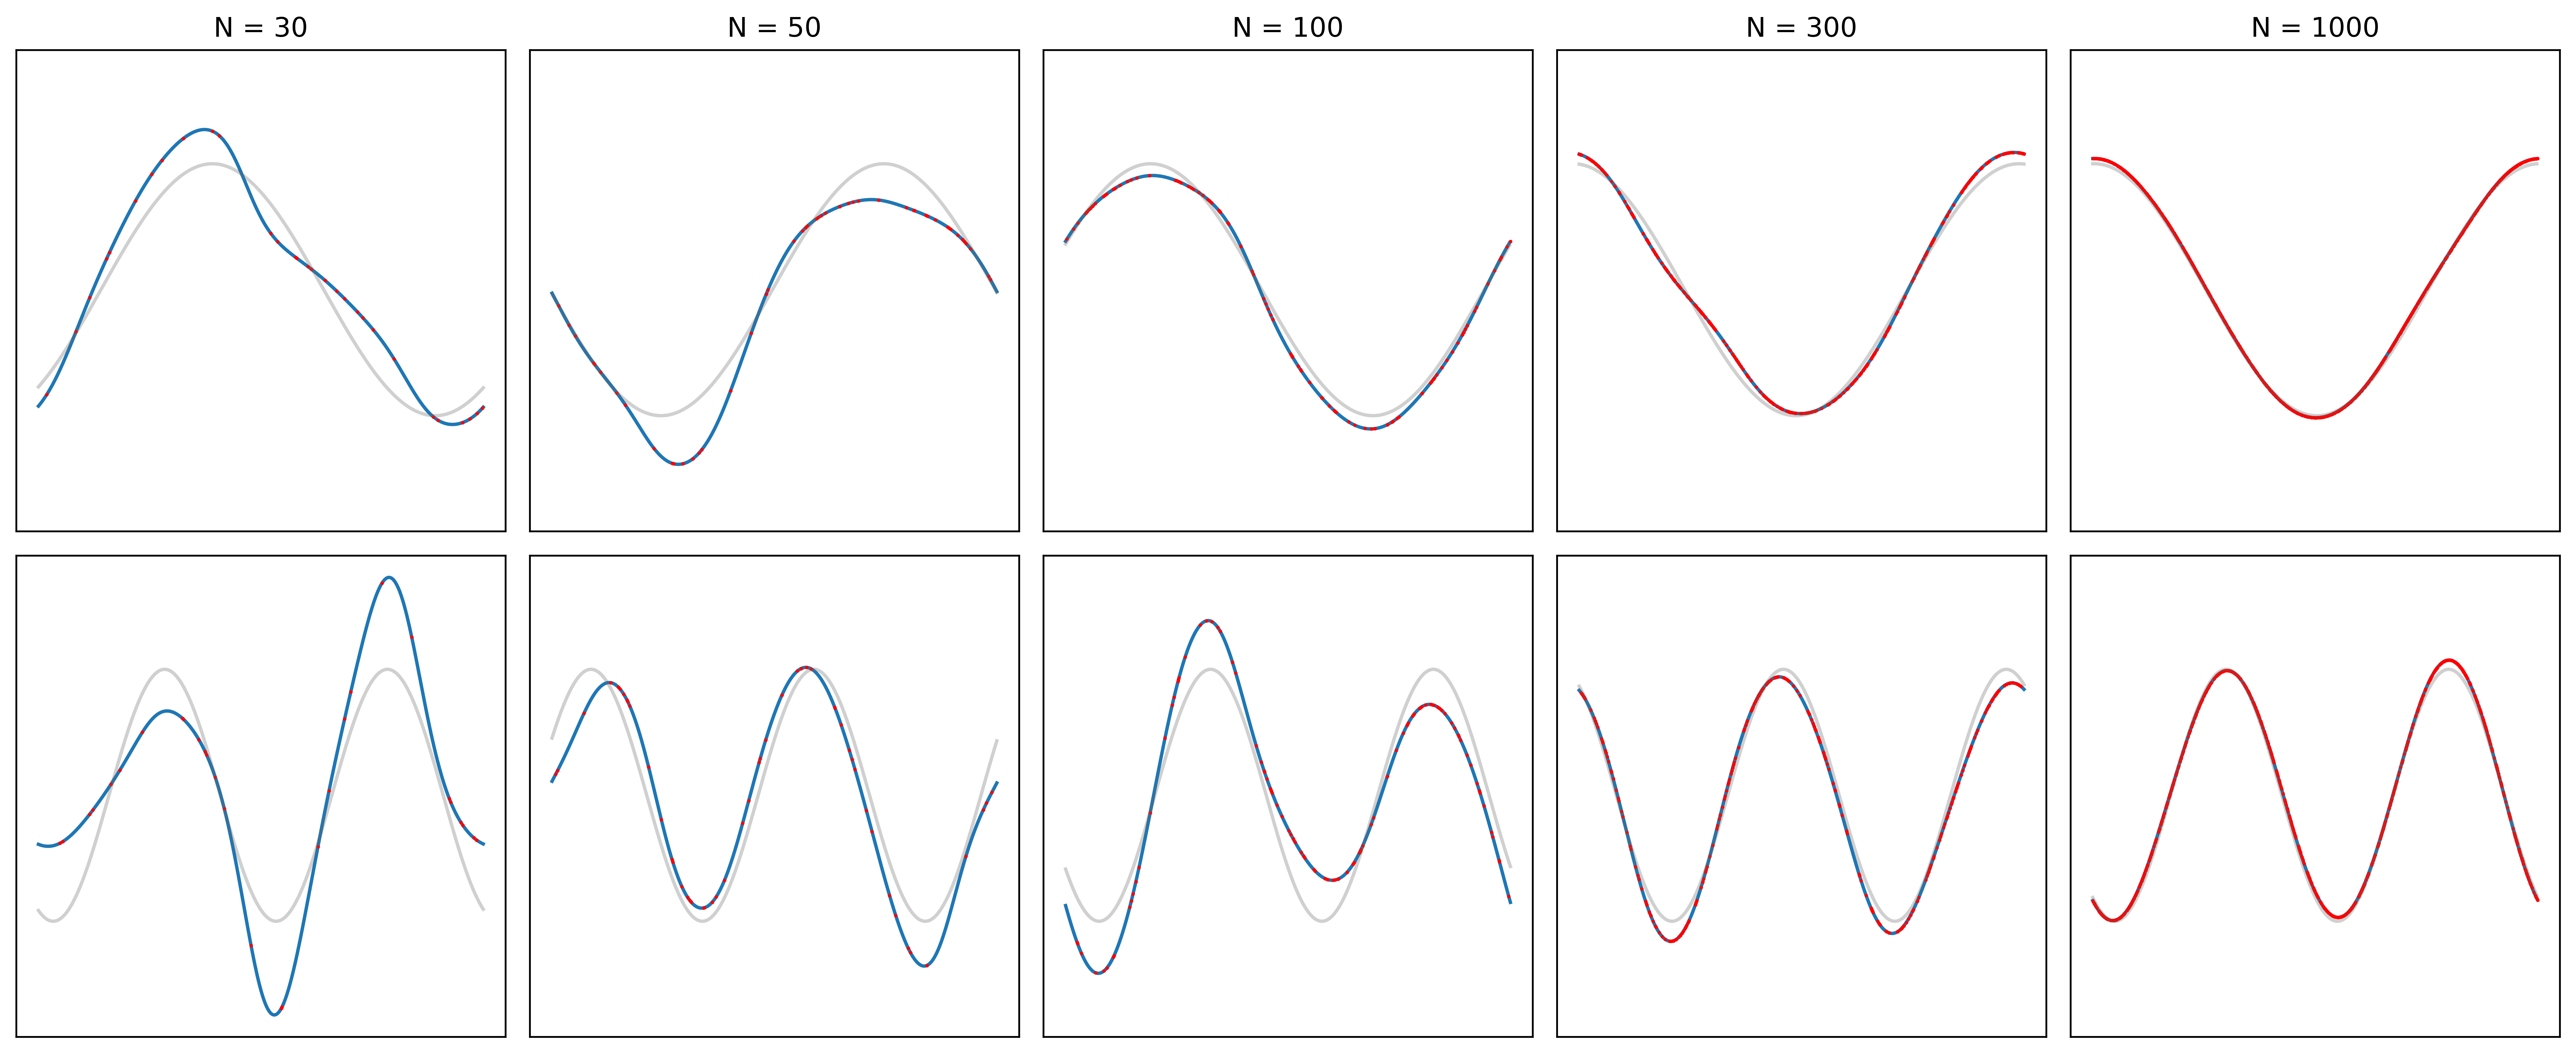

In [41]:
std = 0.01
jump = 0.0
ve = 0.01
nevL = [2,4]
fig,ax = plt.subplots(ncols=5, nrows = len(nevL), layout='tight', figsize=(16,len(nevL) *3.3),dpi=600,facecolor="w", sharey = True)

Nlist = [30,50,100,300,1000]

for i in range(5):
    for j in range(len(nevL)):
        r1,r2,r3,r4, ev = get_eval(gen,Nlist[i], std, ve ,jump , 1, nev = nevL[j])
        rtN = Nlist[i]**.5
        def get_est_l2_dist(x):
            return ((r4[:,None] - (2**.5)* np.sin(2*(j+1) * np.pi * ((r3[:,None]-x[None,:])%1))/(rtN))**2).sum(0)
        phase = np.linspace(0,1,1000)[np.argmin(get_est_l2_dist(np.linspace(0,1,1000)))]
        ax[j,i].plot(r1, rtN*r2/Nlist[i], zorder = 0)
        ax[j,i].plot(r1, rtN*(2**.5)* np.sin(2*(j+1) * np.pi * ((r1-phase)%1))/(r3.shape[0]**.5), zorder = 2, color = (.4,.4,.4), alpha = .3)
        ax[j,i].scatter(r3,rtN*r4, s = .3,zorder = 1,c = 'r')
        ax[j,i].axes.get_xaxis().set_visible(False)
        ax[j,i].axes.get_yaxis().set_visible(False)
        if j == 0:
            ax[j,i].set_title(f"N = {Nlist[i]}", color = 'black')

# Figure 6

In [4]:
Data_6a = get_torus_simulation(gen, Nlist = Nlist, stdL = [.01], epsL = [.01,.0025,.001], shift = .3, shift_prob = .5, dim = 1, N_sim = 100, n_sim = 500).round(5)
Data_6b = get_torus_simulation(gen, Nlist = Nlist, stdL = [.01], epsL = [.01,.0025,.001], shift = .3, shift_prob = .5, dim = 2, N_sim = 100, n_sim = 500).round(5)
Data_6c = get_torus_simulation(gen, Nlist = Nlist, stdL = [.01], epsL = [.01,.0025,.001], shift = .3, shift_prob = .5, dim = 3, N_sim = 100, n_sim = 500).round(5)
Data_6 = pd.concat([Data_6a, Data_6b, Data_6c])

# Data_6 = pd.read_csv('./Given_results_torus/Fig6.csv')

/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, device = dev)
/mnt/vast-nhr/home/bi/u12153/StochasticETO/lib/get_L2_cuda.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y,device = dev)
100%|██████████| 44/44 [11:11<00:00, 15.25s/it]


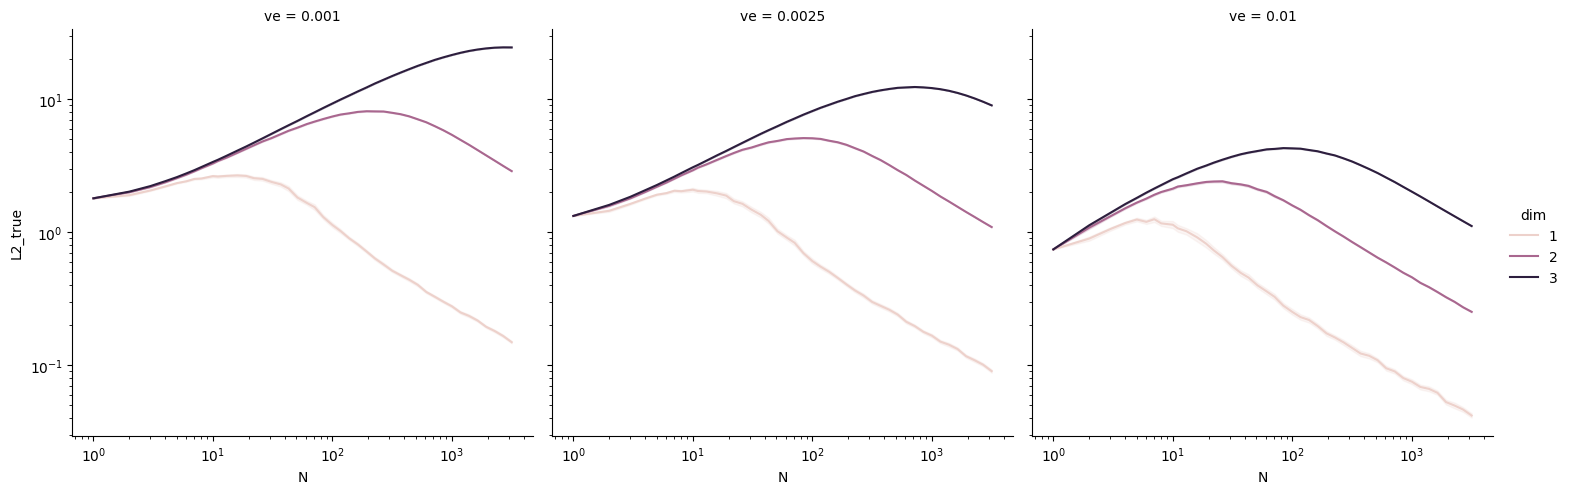

In [12]:
sns.relplot(Data_6, x = 'N', y = 'L2_true', col = 've', hue = 'dim', kind = 'line')
plt.xscale('log')
plt.yscale('log')

# Figure 7

In [7]:
class LinOp:
    def __init__(self, M):
        self.M = M
        self.shape = np.array(M.shape)
        self.dtype = np.float64
    def _matvec(self, v):
        return (self.M @ torch.tensor(v, device = dev)).cpu()
    @property
    def matvec(self):
        return self._matvec

In [8]:
class RandomThiloFunctionClass:
    def __init__(self, Dim, mode_num,damp, R,rotation = True,Fourier_coef = None):
        self.Dim = Dim
        self.mode_num = mode_num
        self.damp = damp
        self.R = R
        if Fourier_coef:
            self.Fourier_coef = Fourier_coef
        else:
            self.Fourier_coef = torch.randn(size = (2,mode_num,Dim), device = dev)
        self.rotation = rotation
        self.Rot = torch.tensor(special_ortho_group.rvs(self.Dim),device = dev,dtype=torch.float32)

    def __call__(self, xgrid):
        d = self.Dim - 2
        mode_num = self.mode_num
        Fourier_coef = self.Fourier_coef
        R = self.R
        damp = self.damp
        xx = damp * torch.sin(torch.arange(1,mode_num+1, device = dev)[:,None] * 2 * torch.pi * xgrid[None,:])/((torch.arange(1,mode_num+1, device = dev)[:,None]))
        yy = damp * torch.cos(torch.arange(1,mode_num+1, device = dev)[:,None] * 2 * torch.pi * xgrid[None,:])/((torch.arange(1,mode_num+1, device = dev)[:,None]))
        pts = (Fourier_coef[0][:,None,:] * xx[:,:,None] + Fourier_coef[1][:,None,:] * yy[:,:,None]).sum(0)
        x1 = R * torch.sin(xgrid * 2 * torch.pi)
        y1 = R * torch.cos(xgrid * 2 * torch.pi)
        main_dim = torch.stack([x1,y1]).T
        Pt = torch.zeros(size = (xgrid.shape[0], d+2), device = dev)
        Pt[:,0:2] = main_dim
        Pt[:,0:2] += damp*pts[:,0:2]
        Pt[:,2:] += pts[:,2:]
        if self.rotation:
            return Pt@self.Rot
        return Pt

In [9]:
Npts = 2000
sft = 1/5
std = .1
x = torch.linspace(0,1,Npts+1,device = dev)[:-1]
C = RandomThiloFunctionClass(Dim = 3,mode_num = 10,damp = .2,R = 1,rotation=True)
xx = C(x)

In [10]:
plot = k3d.plot()
plot += k3d.points(positions = xx.cpu().numpy(),
                   point_size = .1,
                   opacity= .8)

plot.display()

Output()

# Figure 8

In [63]:
C = RandomThiloFunctionClass(Dim = 2,mode_num = 10,damp = .2,R = 1,rotation=1)
ResOTO = {}
ResUlam = {}
Npts = 500
sft = 1/5
epsL = reversed(torch.linspace(1e-1,1e-2,10, device = dev))
stdL = [.05,.1,.2,.4]
for std in tqdm(stdL):
    Res = {
    'evec': [],
    'eval': []
    }
    Res2 = {
    'evec': [],
    'eval':[]
    }
    x = torch.rand(Npts,device = dev)
    y = (x + sft)%1
    xx = C(x)
    yy = C(y)
    xx += std * torch.randn_like(xx,device = dev)
    yy += std * torch.randn_like(yy,device = dev)
    CostX, alphaX, betaX = SolveEW2(xx, xx, epsL)
    CostY, alphaY, betaY = SolveEW2(xx, yy, epsL)
    for i in range(epsL.shape[0]):
        Tx = torch.exp((-torch.cdist(xx, xx)**2 + alphaX[i,:,None] + betaX[i,None,:])/epsL[i])/Npts
        Ty = torch.exp((-torch.cdist(xx, yy)**2 + alphaY[i,:,None] + betaY[i,None,:])/epsL[i])/Npts
        M = (Ty @ Tx)
        Op = sp.sparse.linalg.aslinearoperator(LinOp(M))
        w, v = sp.sparse.linalg.eigs(Op,10,maxiter=10000000, ncv = 200)
        Res['evec'].append(v)
        Res['eval'].append(w)
    ResOTO[std] = Res
    for eps in epsL:
        res_ulam = ulam(xx.cpu().numpy(),yy.cpu().numpy(),binsize=2*eps.item()**.5)
        w, v = sp.sparse.linalg.eigs(res_ulam['T'],min(10,res_ulam['T'].shape[0]-2), ncv = 200)
        Res2['evec'].append(v)
        Res2['eval'].append(w)
    ResUlam[std] = Res2

100%|██████████| 4/4 [00:11<00:00,  2.85s/it]


In [64]:
C = RandomThiloFunctionClass(Dim = 10,mode_num = 10,damp = .2,R = 1,rotation=1)
ResOTO2 = {}
ResUlam2 = {}
Npts = 500
sft = 1/5
epsL = reversed(torch.linspace(1e-1,1e-2,10, device = dev))
stdL = [.05,.1,.2,.4]
for std in tqdm(stdL):
    Res = {
    'evec': [],
    'eval': []
    }
    Res2 = {
    'evec': [],
    'eval':[]
    }
    x = torch.rand(Npts,device = dev)
    y = (x + sft)%1
    xx = C(x)
    yy = C(y)
    xx += std * torch.randn_like(xx,device = dev)
    yy += std * torch.randn_like(yy,device = dev)
    CostX, alphaX, betaX = SolveEW2(xx, xx, epsL)
    CostY, alphaY, betaY = SolveEW2(xx, yy, epsL)
    for i in range(epsL.shape[0]):
        Tx = torch.exp((-torch.cdist(xx, xx)**2 + alphaX[i,:,None] + betaX[i,None,:])/epsL[i])/Npts
        Ty = torch.exp((-torch.cdist(xx, yy)**2 + alphaY[i,:,None] + betaY[i,None,:])/epsL[i])/Npts
        M = (Ty @ Tx)
        Op = sp.sparse.linalg.aslinearoperator(LinOp(M))
        w, v = sp.sparse.linalg.eigs(Op,10,maxiter=10000000, ncv = 200)
        Res['evec'].append(v)
        Res['eval'].append(w)
    ResOTO2[std] = Res
    for eps in epsL:
        res_ulam = ulam(xx.cpu().numpy(),yy.cpu().numpy(),binsize=2*eps.item()**.5)
        w, v = sp.sparse.linalg.eigs(res_ulam['T'],min(10,res_ulam['T'].shape[0]-2), ncv = 200)
        Res2['evec'].append(v)
        Res2['eval'].append(w)
    ResUlam2[std] = Res2

100%|██████████| 4/4 [00:37<00:00,  9.49s/it]


/local/jobs/u12153_11271196/ipykernel_997639/2386184138.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((10 - j)/10), s = 100)
/local/jobs/u12153_11271196/ipykernel_997639/2386184138.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((10 - j)/10), s = 100)
/local/jobs/u12153_11271196/ipykernel_997639/2386184138.py:13: Us

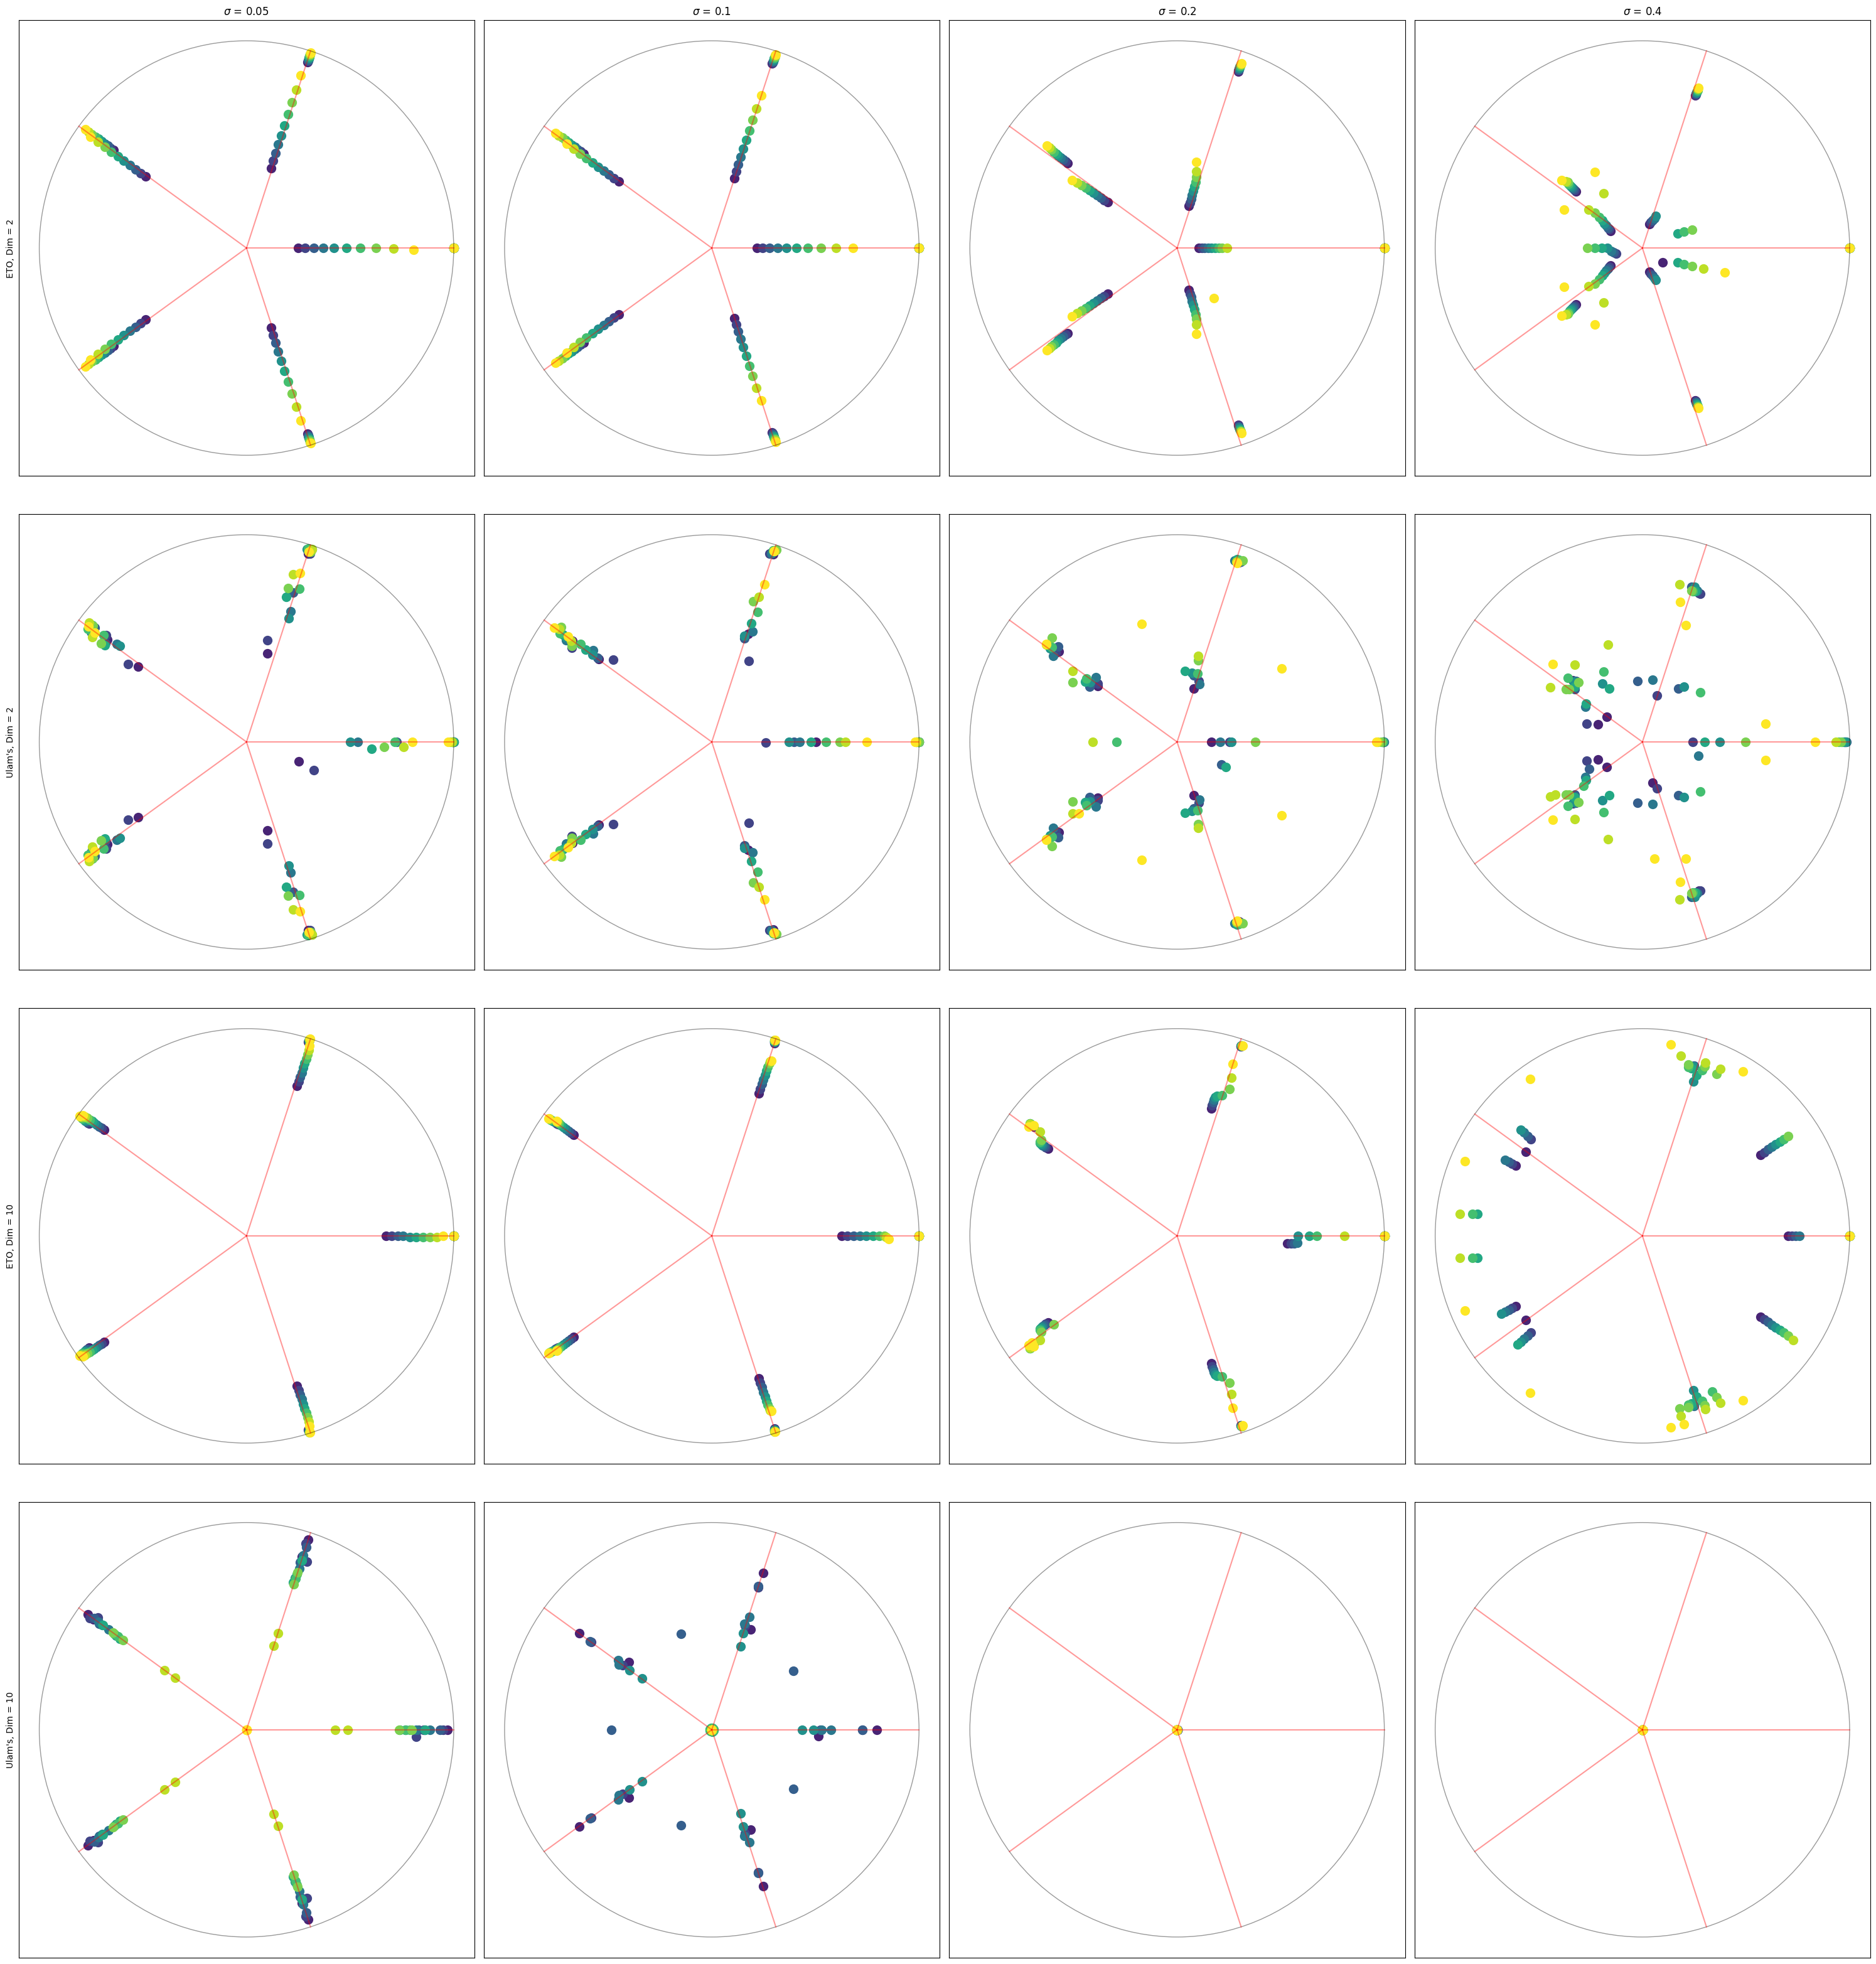

In [67]:
stdL = [t for t in ResOTO]
fig, ax = plt.subplots(ncols = len(stdL), nrows = 4, figsize = (15*2,8*4),sharex = True, sharey = True)

for i, std in enumerate(stdL):
    ax[0,i].set_title(f"$\sigma$ = {std}")
    for j in range(10)[::-1]:
        ev = ResOTO[std]['eval'][j]
        ev2 = ResUlam[std]['eval'][j]
        ax[0,i].scatter(ev.real, ev.imag, c = cm.viridis((10 - j)/10), s = 100)
        ax[1,i].scatter(ev2.real, ev2.imag, c = cm.viridis((10 - j)/10), s = 100)
        ev = ResOTO2[std]['eval'][j]
        ev2 = ResUlam2[std]['eval'][j]
        ax[2,i].scatter(ev.real, ev.imag, c = cm.viridis((10 - j)/10), s = 100)
        ax[3,i].scatter(ev2.real, ev2.imag, c = cm.viridis((10 - j)/10), s = 100)
for a in ax.ravel():
        
    for k in range(5):
        a.plot([0,np.cos(2*np.pi*k/5)],[0,np.sin(2*np.pi*k/5)], c = 'red', alpha = .4)
    circ = plt.Circle((0.0, 0.0), 1.0, facecolor='none', edgecolor='k', lw=1, alpha = .4)
    a.set_aspect('equal')
    a.set_xlim([-1.1,1.1])
    a.set_ylim([-1.1,1.1])
    a.set_xticks([])
    
    a.set_yticks([])
    a.add_patch(circ)
    a.set_ylabel('')
ax[0,0].set_ylabel(f"ETO, Dim = 2")
ax[1,0].set_ylabel(f"Ulam's, Dim = 2")
ax[2,0].set_ylabel(f"ETO, Dim = 10")
ax[3,0].set_ylabel(f"Ulam's, Dim = 10")
plt.tight_layout()
